<a href="https://colab.research.google.com/github/varaiitj2527/PRMLProject/blob/main/Model/Logistic_Regression/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/varaiitj2527/PRMLProject.git
%cd PRMLProject

Cloning into 'PRMLProject'...
remote: Enumerating objects: 118, done.
remote: Counting objects: 100% (100/100), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 118 (delta 32), reused 21 (delta 2), pack-reused 18 (from 2)
Receiving objects: 100% (118/118), 206.29 MiB | 24.31 MiB/s, done.
Resolving deltas: 100% (32/32), done.
Updating files: 100% (40/40), done.
Filtering content: 100% (14/14), 1.29 GiB | 55.21 MiB/s, done.
Encountered 2 file(s) that should have been pointers, but weren't:
	PreProcessedData/quicknet_test.pkl
	PreProcessedData/quicknet_train.pkl
/content/PRMLProject


In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt

In [ ]:
def unpickle(filename) :

  with open(filename, 'rb') as file :
      data = pickle.load(file, encoding='bytes')

  return data


In [ ]:
train_RawData = unpickle('PreProcessedData/RawPixels_train.pkl')
test_RawData = unpickle('PreProcessedData/RawPixels_test.pkl')

y_train = unpickle('PreProcessedData/Labels_train.pkl')
y_test = unpickle('PreProcessedData/Labels_test.pkl')

train_PcaData = unpickle('PreProcessedData/TrainFeaturesPCA.pkl')
test_PcaData = unpickle('PreProcessedData/TestFeaturesPCA.pkl')

train_HoGData = unpickle('PreProcessedData/TrainFeaturesHoG.pkl')
test_HoGData = unpickle('PreProcessedData/TestFeaturesHoG.pkl')

train_Pca_HoGData = unpickle('PreProcessedData/TrainFeaturesPCA_HoG.pkl')
test_Pca_HoGData = unpickle('PreProcessedData/TestFeaturesPCA_HoG.pkl')

train_HoG_PcaData = unpickle('PreProcessedData/TrainFeaturesHoG_PCA.pkl')
test_HoG_PcaData = unpickle('PreProcessedData/TestFeaturesHoG_PCA.pkl')

train_ResnetData = unpickle('PreProcessedData/Resnet_train.pkl')
test_ResnetData = unpickle('PreProcessedData/Resnet_test.pkl')

# train_QuicknetData = unpickle('PreProcessedData/quicknet_train.pkl')
# test_QucicknetData = unpickle('PreProcessedData/quicknet_test.pkl')

In [ ]:
train_QuicknetData = unpickle('quicknet_train.pkl')
test_QuicknetData = unpickle('quicknet_test.pkl')

In [ ]:
import tensorflow as tf
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def Confusion(y_test, y_pred) :

    cm = confusion_matrix(np.argmax(y_test, axis=1), y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

def logReg(X_train, y_train, X_test, y_test) :

    model = LogisticRegression(max_iter=5000)
    model.fit(X_train, np.argmax(y_train, axis=1))
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(np.argmax(y_test, axis=1), y_pred)
    Confusion(y_test, y_pred)
    return accuracy


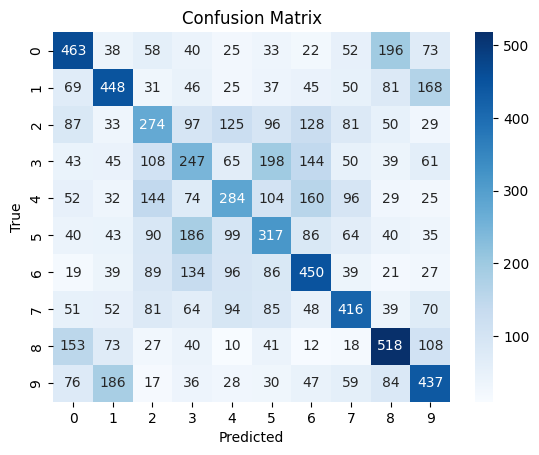

Raw Accuracy :  0.3854


In [ ]:
train_RawData = (train_RawData.reshape(-1,3072)).astype('float32') / 255
test_RawData = (test_RawData.reshape(-1,3072)).astype('float32') / 255
Raw_accuracy = logReg(train_RawData, y_train, test_RawData, y_test)
print("Raw Accuracy : ", Raw_accuracy)

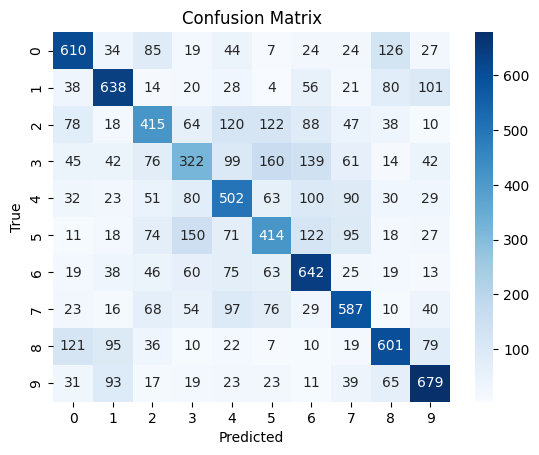

HoG Accuracy :  0.541


In [ ]:
HoG_accuracy = logReg(train_HoGData, y_train, test_HoGData, y_test)
print("HoG Accuracy : ", HoG_accuracy)

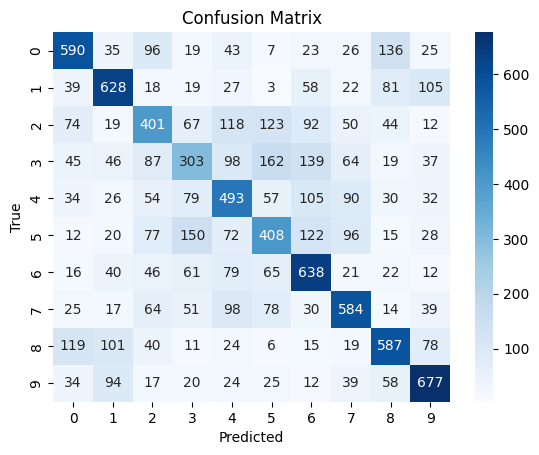

HoG_PCA Accuracy :  0.5309


In [ ]:
HoG_PCA_accuracy = logReg(train_HoG_PcaData, y_train, test_HoG_PcaData, y_test)
print("HoG_PCA Accuracy : ", HoG_PCA_accuracy)

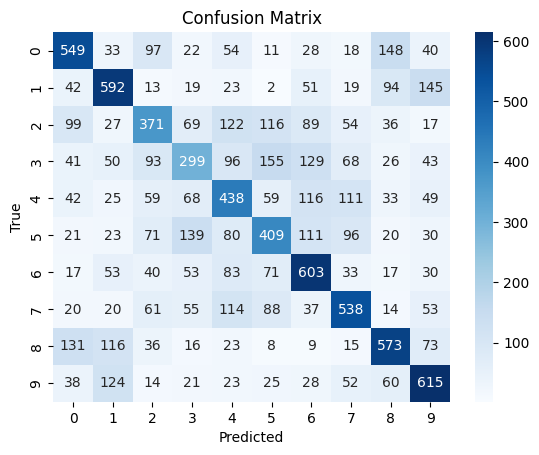

PCA_HoG Accuracy :  0.4987


In [ ]:
PCA_HoG_accuracy = logReg(train_Pca_HoGData, y_train, test_Pca_HoGData, y_test)
print("PCA_HoG Accuracy : ",PCA_HoG_accuracy)

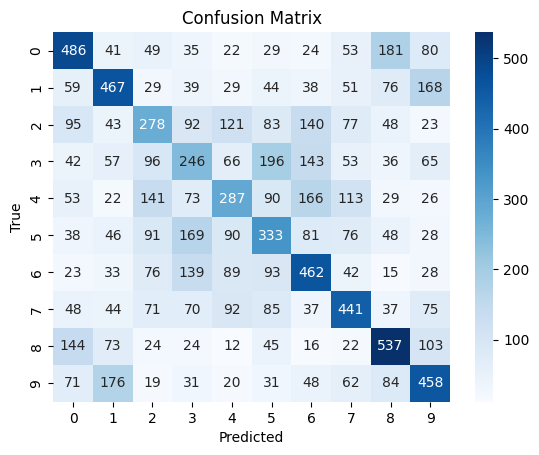

PCA Accuracy :  0.3995


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
train_PcaData = scaler.fit_transform(train_PcaData)
test_PcaData = scaler.transform(test_PcaData)
PCA_accuracy = logReg(train_PcaData, y_train, test_PcaData, y_test)
print("PCA Accuracy : ", PCA_accuracy)

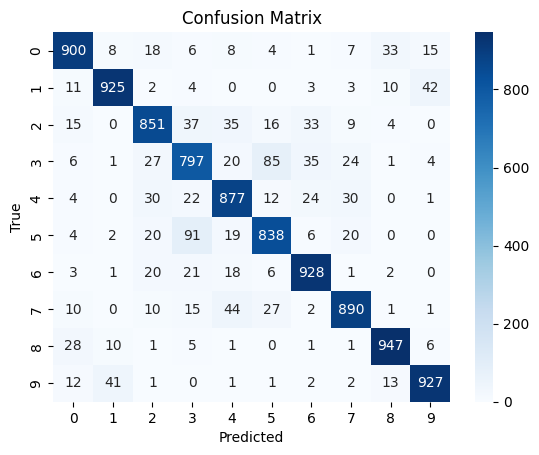

Resnet Accuracy :  0.888


In [ ]:
Resnet_accuracy = logReg(train_ResnetData, y_train, test_ResnetData, y_test)
print("Resnet Accuracy : ", Resnet_accuracy)

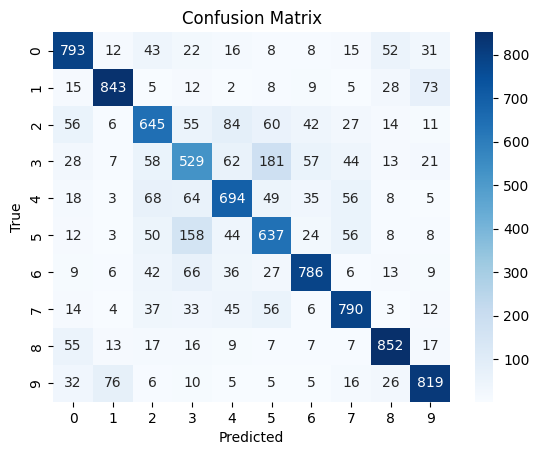

Quicknet Accuracy :  0.7388


In [ ]:
Quicknet_accuracy = logReg(train_QuicknetData, y_train, test_QuicknetData, y_test)
print("Quicknet Accuracy : ",Quicknet_accuracy)